# The models

This notebook accompanies Chapter 3 of the manual
(`docs/03_models.md`). The chapter explains the ideas; here we build the
networks, look inside a trained checkpoint, and load it back into a model.

We answer four questions:

1. Which models were trained, and on which datasets?
2. What do the two architectures (MLP and CNN) look like?
3. What do the trained weights actually look like?
4. How do the checkpoints let us revive a trained model without a GPU?

Figures produced (shown in the chapters):
`outputs/figures/03_weights.png`, `03_weights_epochs.png`.

In [1]:
# Note: no `matplotlib.use("Agg")` here — plain `python` runs fall back to a
# headless backend automatically, and the Jupyter kernel uses the inline
# backend, so the same code saves PNGs *and* displays figures in notebooks.
import matplotlib.pyplot as plt
import numpy as np

from feature_emergence.config import MODELS_DIR, OUTPUTS_DIR

out = OUTPUTS_DIR / "figures"
out.mkdir(parents=True, exist_ok=True)

## 1. Which models were trained?

The study trains one network per (dataset, architecture) combination. Each
combination fixes the leakage model of [Chapter 1](../../docs/01_introduction.md):
ASCADr uses the identity model (256 classes, one per S-box output value),
ESHARD and CHES_CTF use the Hamming weight model (9 classes).

The training runs left one checkpoint per epoch in `models/` — the counts
below tell us which combinations exist:

In [2]:
from collections import Counter

prefixes = Counter()
for p in MODELS_DIR.glob("*_*.weights.h5"):
    prefixes[p.name.rsplit("_", 1)[0]] += 1

print(f"{'model':18s} checkpoints")
for name in sorted(prefixes):
    print(f"{name:18s} {prefixes[name]}")

model              checkpoints
cnn_ascadr         100
cnn_eshard         100
mlp_ascadr         100
mlp_ches_ctf       200
mlp_eshard         1
mlp_eshard_        100


Five model families in total. Not every architecture was run on every
dataset — for CHES_CTF only the MLP is available, and ESHARD was run with
both. Most families have 100 checkpoints, one per training epoch; the
CHES_CTF run extends to 200. (A naming slip in the published files —
`mlp_eshard__01` with a double underscore — splits one family across two
prefixes in the table above.)

## 2. The two architectures

The two families differ in how they read a trace:

- **MLP** — a stack of dense layers. Every input sample is multiplied by its
  own weight, so the network can learn "sample *t* matters with weight *w*".
  It has no notion of neighbouring samples.
- **CNN** — 1-D convolutions slide small kernels along the trace, so the
  network learns local shapes (a spike, a dip) rather than individual
  samples. Fewer parameters, but a less direct mapping from samples to
  weights.

The exact stacks, as defined in the package:

In [3]:
from feature_emergence.profiling_and_attack import cnn_eshard, mlp

# ASCADr model: identity leakage model -> 256 output classes
model = mlp(classes=256, number_of_samples=2000)
model.summary()

2026-09-09 02:58:31.642593: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-09 02:58:31.690114: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-09-09 02:58:31.690156: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-09 02:58:31.691594: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-09-09 02:58:31.699125: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-09 02:58:31.699667: I tensorflow/core/platform/cpu_feature_guard.cc:1

2026-09-09 02:58:32.693011: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Model: "mlp_softmax"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


...

 output (Dense)              (None, 256)               25856     


Total params: 276456 (1.05 MB)


Trainable params: 276456 (1.05 MB)


Non-trainable params: 0 (0.00 Byte)


_________________________________________________________________


In [4]:
# ESHARD CNN: Hamming weight leakage model -> 9 output classes
cnn = cnn_eshard(classes=9, number_of_samples=1400)
cnn.summary()

Model: "mlp_softmax"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 input_layer (InputLayer)    [(None, 1400, 1)]         0         


 conv1d (Conv1D)             (None, 279, 16)           176       


...

 output (Dense)              (None, 9)                 909       


Total params: 58229 (227.46 KB)


Trainable params: 58133 (227.08 KB)


Non-trainable params: 96 (384.00 Byte)


_________________________________________________________________


Two things worth noticing in the summaries:

- The MLP is a deep stack of six `Dense(100)` layers with ELU activations —
  small layers, many of them. Its input is the 2,000-sample ASCADr trace,
  its output a probability for each of the 256 S-box output values.
- The CNN compresses the 1,400-sample ESHARD trace through two
  convolution + average-pooling blocks before its dense layers.

## 3. Inside the weights

A checkpoint is itself an HDF5 file — the same container format as the
datasets of [Chapter 2](../../docs/02_the_data.md), opened with the same
tool, `h5py`. Inside, the weights are plain numerical arrays. Let's open
one and list what it holds:

In [5]:
import h5py

CKPT = MODELS_DIR / "mlp_ascadr_100.weights.h5"

with h5py.File(CKPT, "r") as f:
    def show(name, obj):
        if isinstance(obj, h5py.Dataset) and name.startswith("layers"):
            print(f"{name:35s} shape={str(obj.shape):14s}")
    f.visititems(show)

layers/dense/vars/0                 shape=(2000, 100)   
layers/dense/vars/1                 shape=(100,)        
layers/dense_1/vars/0               shape=(100, 100)    
layers/dense_1/vars/1               shape=(100,)        
layers/dense_2/vars/0               shape=(100, 100)    
layers/dense_2/vars/1               shape=(100,)        
layers/dense_3/vars/0               shape=(100, 100)    
layers/dense_3/vars/1               shape=(100,)        
layers/dense_4/vars/0               shape=(100, 100)    
layers/dense_4/vars/1               shape=(100,)        
layers/dense_5/vars/0               shape=(100, 100)    
layers/dense_5/vars/1               shape=(100,)        
layers/dense_6/vars/0               shape=(100, 256)    
layers/dense_6/vars/1               shape=(256,)        


The layout mirrors the network: one group per layer, and per layer two
arrays — the weight matrix (`vars/0`) and the biases (`vars/1`). The first
entry, `layers/dense/vars/0`, has shape (2000, 100): **one weight per (time
sample, neuron) pair**. Each of the 100 first-layer neurons holds its own
list of 2,000 weights — its private "listening profile" over the trace.

We can look at the whole matrix at once:

saved: /workspace/outputs/figures/03_weights.png


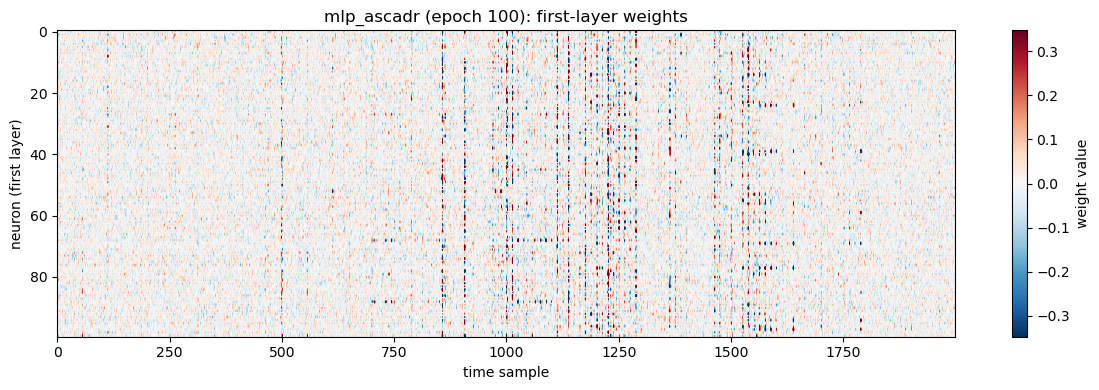

In [6]:
with h5py.File(CKPT, "r") as f:
    W = f["layers/dense/vars/0"][:]          # (2000 samples, 100 neurons)

v = float(np.percentile(np.abs(W), 99))      # color range ignoring outliers

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(W.T, aspect="auto", cmap="RdBu_r", vmin=-v, vmax=v)
ax.set_title("mlp_ascadr (epoch 100): first-layer weights")
ax.set_xlabel("time sample")
ax.set_ylabel("neuron (first layer)")
fig.colorbar(im, ax=ax, label="weight value")

fig.tight_layout()
fig.savefig(out / "03_weights.png", dpi=150)
print("saved:", out / "03_weights.png")
plt.show()

### The weights at a few epochs

The heatmap above is the *end* of training. Because there is one checkpoint
per epoch, we can replay how it got there — the same matrix, read from a
few checkpoints along the way. All panels share one color scale, fixed by
the final epoch, so the change is visible rather than re-normalized away.

/tmp/ipykernel_14/1720144959.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved: /workspace/outputs/figures/03_weights_epochs.png


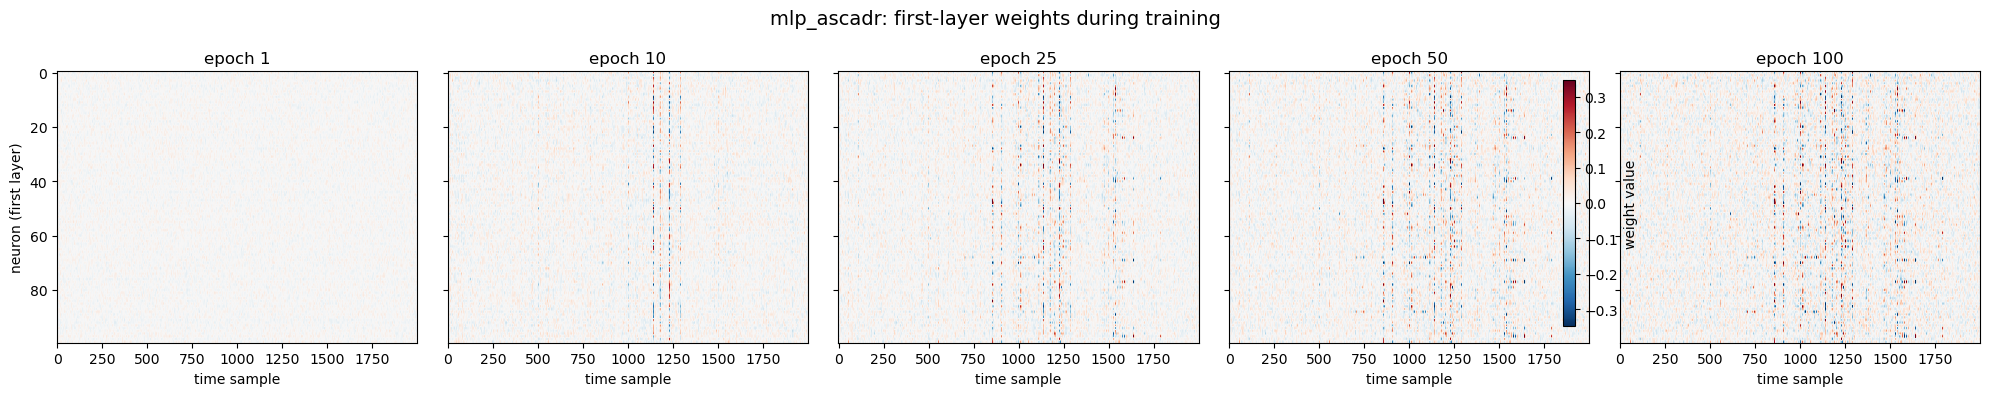

In [7]:
EPOCHS = [1, 10, 25, 50, 100]

mats = []
for e in EPOCHS:
    with h5py.File(MODELS_DIR / f"mlp_ascadr_{e:02d}.weights.h5", "r") as f:
        mats.append(f["layers/dense/vars/0"][:])

v = float(np.percentile(np.abs(mats[-1]), 99))  # one color scale for all panels

fig, axes = plt.subplots(1, len(EPOCHS), figsize=(20, 4), sharey=True)
for ax, e, W in zip(axes, EPOCHS, mats):
    im = ax.imshow(W.T, aspect="auto", cmap="RdBu_r", vmin=-v, vmax=v)
    ax.set_title(f"epoch {e}")
    ax.set_xlabel("time sample")
axes[0].set_ylabel("neuron (first layer)")
fig.colorbar(im, ax=axes, label="weight value", shrink=0.8)
fig.suptitle("mlp_ascadr: first-layer weights during training", fontsize=14)
fig.tight_layout()

fig.savefig(out / "03_weights_epochs.png", dpi=150)
print("saved:", out / "03_weights_epochs.png")
plt.show()

At epoch 1 the matrix is initialization noise — no sample stands out. As
training progresses, structure condenses: bands of color appear at specific
time samples, meaning many neurons have learned to listen there. Measuring
*when* this happens, and whether the loud samples coincide with the SNR
peaks of [Chapter 2](../../docs/02_the_data.md), is the feature-emergence
question of a later chapter.

Each column of the image is one neuron's 2,000 weights along the trace.
Where a column is strongly colored, that neuron weights those samples
heavily; where it is white, it ignores them. At this point we only note the
*shape* of the thing — which of these weights come to matter, and when, is
the question of a later chapter.

## 4. Checkpoints: the weights of every epoch

Training these networks takes hours on a GPU — which we do not have. The
authors therefore published **checkpoints**: the file above, saved after
*each* training epoch, `..._01.weights.h5` through `..._100.weights.h5`.

Loading checkpoint *k* into a freshly built network revives the model
*exactly as it was after epoch k*. Nothing is retrained:

In [8]:
model.load_weights(CKPT)
print("loaded:", CKPT.name, "(weights after epoch 100)")

loaded: mlp_ascadr_100.weights.h5 (weights after epoch 100)


The network now behaves exactly like the trained model of epoch 100 — same
weights, same predictions. What it *does* with a trace is the subject of
[the next chapter](../../docs/04_the_attack.md).

## Takeaways

- Five model families were trained (MLP/CNN × three datasets), each saved as
  per-epoch checkpoints (100 per family, 200 for CHES_CTF) — no GPU is
  needed to use them.
- The MLP reads individual samples; the CNN reads local shapes. Both output
  a probability per leakage class.
- A checkpoint is an HDF5 file whose arrays are the trained weights; the
  first MLP layer stores one weight per (time sample, neuron) pair.
- Loading checkpoint *k* revives the model as it stood after epoch *k* —
  the trick that makes the whole study reproducible on a laptop.